In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import sys
sys.path.insert(0, "/zhome/71/c/146676/texture_tomography/maptools")
import maptools
import os

import matplotlib.pyplot as plt
import h5py
import hdf5plugin
from tqdm.notebook import tqdm


from scipy.ndimage import median_filter, minimum_filter, maximum_filter, gaussian_filter
from skimage.transform import iradon

maptools.job.info()
maptools.plot.dark()
!which python

import time

import ImageD11.columnfile

hostname: n-62-11-21
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 24
Memory available: 799.7345792 GB
~/miniconda3/envs/textom/bin/python


In [2]:
h5path = maptools.paths.RAW_PEAKFILES["scan-0053"]
m = 0
ykeys, yvals = [], []
for h5path in maptools.paths.RAW_PEAKFILES.values():
    with h5py.File(h5path, "r") as f:
        for k in f.keys():
            if k not in ykeys:
                ykeys.append(k)
                yvals.append(f[k]["dty"][0])
                m += len(f[k]["dty"])

In [3]:
pks = {
    "s_1": np.zeros((m,), dtype=np.uint16),
    "s_I": np.zeros((m,), dtype=np.uint32),
    "o_raw": np.zeros((m,), dtype=np.float32),
    "dty": np.zeros((m,), dtype=np.float32),
    "f_raw": np.zeros((m,), dtype=np.float32),
    "s_raw": np.zeros((m,), dtype=np.float32),
}

ii = 0
paths = list(maptools.paths.RAW_PEAKFILES.values())
ykeys = []

bar = tqdm(total=m, leave=False)
for h5path in paths:
    with h5py.File(h5path, "r") as f:
        for k in f.keys():
            if k not in ykeys:
                ykeys.append(k)
                for pk in pks.keys():
                    data = f[k][pk][:]
                    pks[pk][ii : ii + len(data)] = data.astype(pks[pk].dtype)
                ii += len(data)
                bar.update(len(data))
bar.close()

  0%|          | 0/752356569 [00:00<?, ?it/s]

In [5]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/pks.h5' )
maptools.io.write_peaks(pks, h5path)

In [7]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)

colf.filter(colf.sum_intensity > 100)

pks = {
    "s_1": colf.Number_of_pixels,
    "s_I": colf.sum_intensity,
    "o_raw": colf.omega,
    "dty": colf.dty,
    "f_raw": colf.fc,
    "s_raw": colf.sc,
}
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/medium_pks.h5' )
maptools.io.write_peaks(pks, h5path)


In [8]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)

colf.filter(colf.sum_intensity > 500)

pks = {
    "s_1": colf.Number_of_pixels,
    "s_I": colf.sum_intensity,
    "o_raw": colf.omega,
    "dty": colf.dty,
    "f_raw": colf.fc,
    "s_raw": colf.sc,
}
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/strong_pks.h5' )
maptools.io.write_peaks(pks, h5path)


In [9]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/medium_pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)

In [10]:
dty_centers = np.unique(colf.dty.round(3))
dty_step = dty_centers[1] - dty_centers[0]
dty_bins = dty_centers - dty_step/2.
dty_bins = np.concatenate([dty_bins, [dty_bins[-1] + dty_step]])

ome_centers = np.unique(colf.omega.round(3))
ome_step = ome_centers[1] - ome_centers[0]
ome_bins = ome_centers - ome_step/2.
ome_bins = np.concatenate([ome_bins, [ome_bins[-1] + ome_step]])

In [11]:
h, _, _ = np.histogram2d(colf.omega, colf.dty, bins=(ome_bins, dty_bins), weights=colf.Number_of_pixels )
sino = h.copy()
sino = sino.T
sino /= np.max(sino, axis=0)

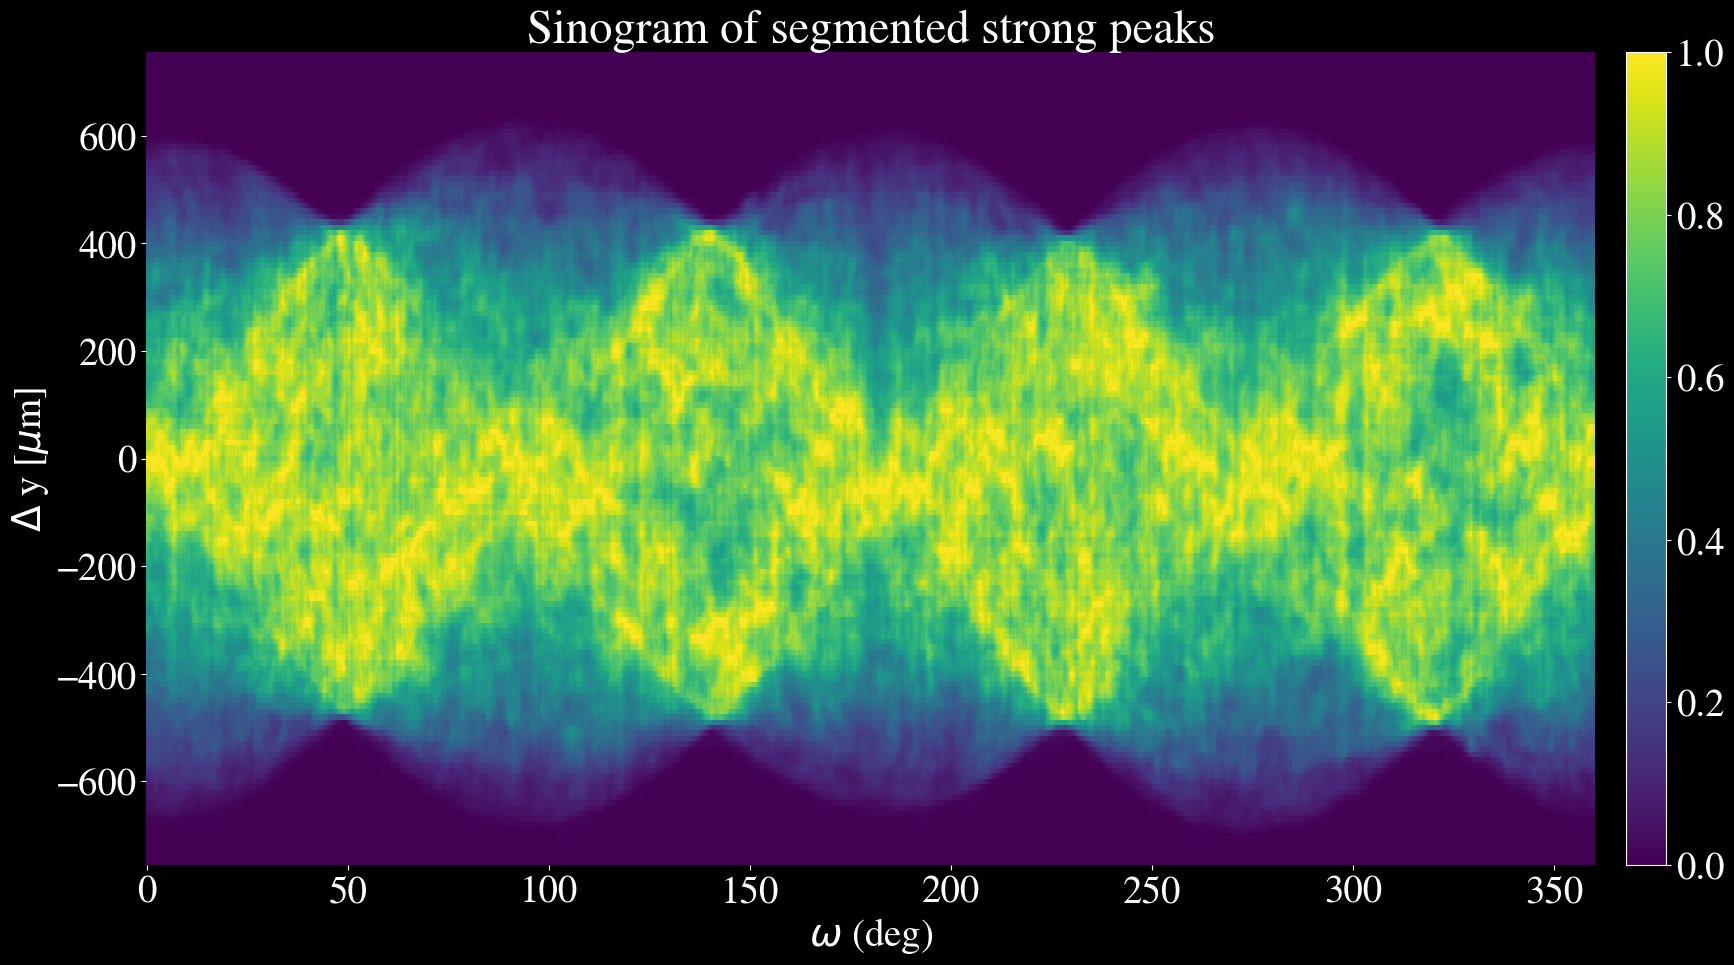

In [12]:
X, Y = np.meshgrid(ome_centers, dty_centers)
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
im = ax.pcolormesh(X, Y*1000, sino, cmap='viridis', shading='nearest')
ax.set_xlabel(r'$\omega$ (deg)')
ax.set_ylabel(r'$\Delta$ y [$\mu$m]')
fig.colorbar(im, ax=ax, fraction=0.028, pad=0.02)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
ax.set_title('Sinogram of segmented strong peaks')
plt.show()

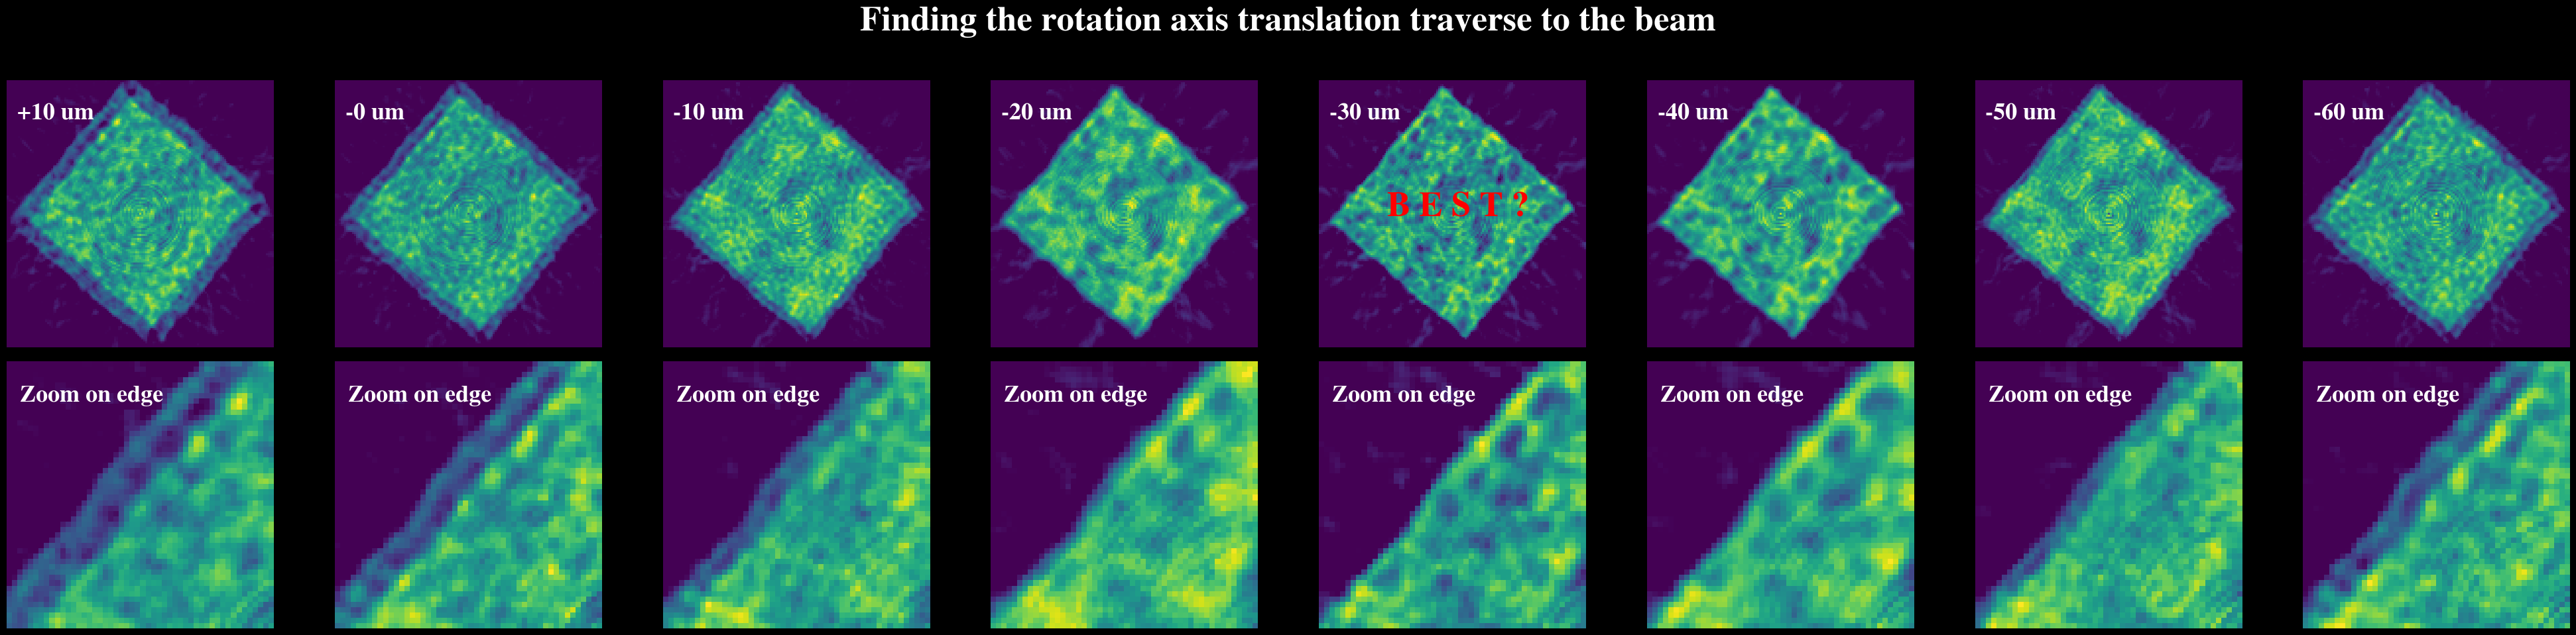

In [13]:
msino = sino.copy()
uni_omega = ome_centers

recs = [ (iradon(np.roll(msino, i, axis=0), theta=uni_omega), i) for i in range(-1, 7, 1) ]

fig, ax = plt.subplots(2, len(recs), figsize=(40, 10))
for i in range(len(recs)):
    rr, ii = recs[i]
    ax[0,i].imshow(rr.clip(np.max(rr)*0.05)[6:-6, 6:-6], interpolation='nearest')
    s = '+' if ii<0 else '-'
    ax[0,i].text(5, 20, s + str(abs(np.round(ii*dty_step*1000,0).astype(int)))+' um', fontsize=26, fontweight='bold')
    ax[1,i].text(2, 7, 'Zoom on edge', fontsize=26, fontweight='bold')
    if ii==3:
        ax[0,i].text(35, 70, 'B E S T ?', fontsize=38, color='r', fontweight='bold')
    ax[1,i].imshow(rr.clip(np.max(rr)*0.05)[20:70, 20:70], interpolation='nearest')
for a in ax.flatten():
    a.axis('off')
    for spine in a.spines.values():
        spine.set_visible(False)
fig.suptitle('Finding the rotation axis translation traverse to the beam', fontsize=38, fontweight='bold')
plt.tight_layout()
#fig.savefig('finding_rotation_axis.png', dpi=400)
plt.show()

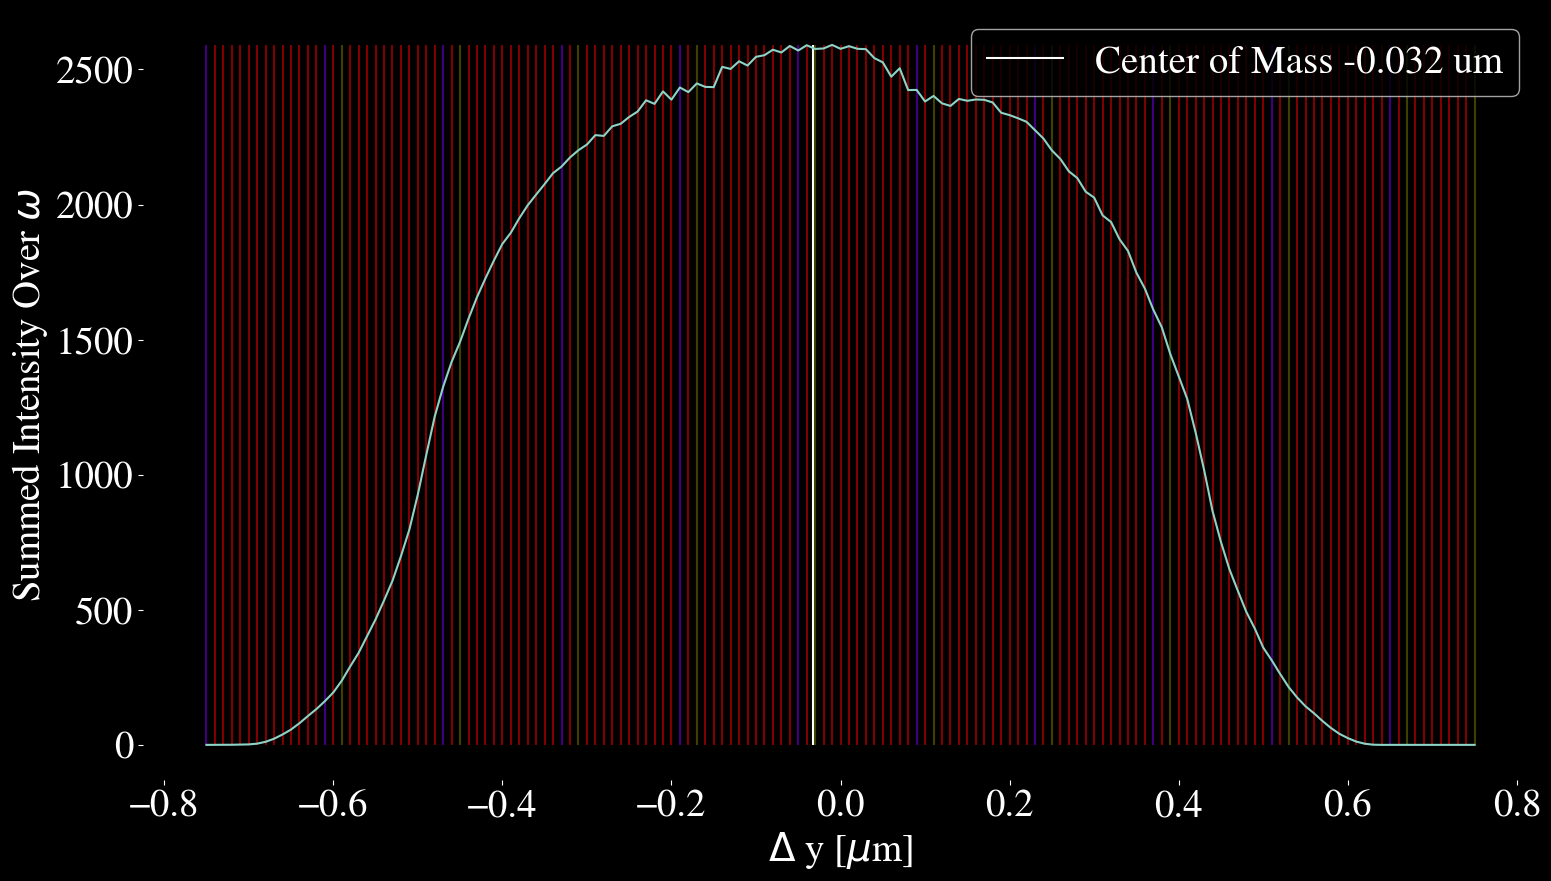

In [14]:
profile = np.sum(sino, axis=1)

com = np.sum(profile * dty_centers) / np.sum(profile)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

for dty in dty_centers:
    ax.vlines(dty, 0, np.max(profile), color='r', linestyle='-', alpha=0.5)

ax.vlines(com, 0, np.max(profile), color='w', linestyle='-', label=f'Center of Mass {com:.3f} um')
ax.legend()
for k in maptools.constants.SCANRANGES:
    ax.vlines(maptools.constants.SCANRANGES[k][0], 0, np.max(profile), color='b', linestyle='-', alpha=0.5)
    ax.vlines(maptools.constants.SCANRANGES[k][1], 0, np.max(profile), color='g', linestyle='-', alpha=0.5)
ax.set_xlabel(r'$\Delta$ y [$\mu$m]')
ax.set_ylabel('Summed Intensity Over $\omega$')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.plot(dty_centers, profile)
plt.show()